# 02 — Train Surrogates (Modelos aproximadores)


In [2]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.base import clone

import joblib

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DIR_BASE = "./Datos/Transformados/Optimizacion"

DATA_PATH = os.path.join(DIR_BASE, "eda", "dataset_clean.csv")
OUT_DIR = os.path.join(DIR_BASE, "modelos_surrogates")
FIG_DIR = os.path.join(OUT_DIR, "figures")
MODEL_DIR = os.path.join(DIR_BASE, "models", "surrogates")

os.makedirs(DIR_BASE, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

pd.set_option("display.max_columns", 200)

## 1) Carga del dataset + renombrado de columnas


In [3]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
display(df.head())

# Columnas del problema
columnas_X = ["hm", "alpha_m", "er", "dsi", "bst", "bss"]
columnas_Y = ["TC", "TcogPP", "ned", "TriPP"]

# Verificar que existen
faltantes = [c for c in columnas_X + columnas_Y if c not in df.columns]
assert not faltantes, f"Faltan columnas esperadas: {faltantes}"

# Seleccionar solo columnas necesarias
df_xy = df[columnas_X + columnas_Y].copy()

# Limpieza básica
df_xy.replace([np.inf, -np.inf], np.nan, inplace=True)


print("Rows after cleaning:", len(df_xy))
display(df_xy.describe().T)

# Alias para mantener compatibilidad con el resto del notebook
X_cols = columnas_X
Y_cols = columnas_Y

Shape: (1700, 10)


,hm,alpha_m,er,dsi,bst,bss,TC,TcogPP,ned,TriPP
0,3.2,0.95,1.2,2.4,46.5,5.1,7.543477,0.000590,-0.809682,0.002764
1,1.2,0.95,1.0,0.1,45.0,4.8,5.377060,0.206311,-0.918555,0.225746
2,1.2,0.75,1.3,0.4,48.0,4.8,5.048992,0.033728,-0.908788,0.060608
3,1.4,0.85,0.8,0.1,49.0,4.7,5.681045,0.238174,-0.917285,0.244254
4,1.2,0.90,2.0,0.1,45.0,4.8,5.177121,0.016478,-0.914834,0.054130


Rows after cleaning: 1700


,count,mean,std,min,25%,50%,75%,max
hm,1700.0,2.161765,1.106701,1.000000,1.200000,1.600000,3.200000,4.000000
alpha_m,1700.0,0.858353,0.096439,0.700000,0.750000,0.900000,0.900000,1.000000
er,1700.0,1.404647,0.414633,0.600000,1.100000,1.400000,1.800000,2.000000
dsi,1700.0,0.993353,0.951618,0.000000,0.100000,0.700000,2.100000,2.500000
bst,1700.0,46.152941,1.129553,45.000000,45.000000,46.000000,46.500000,49.500000
bss,1700.0,4.729353,0.546747,3.500000,4.700000,4.800000,5.100000,5.900000
TC,1700.0,6.190064,1.264042,4.458092,5.066071,5.843123,7.304702,9.711661
TcogPP,1700.0,0.075674,0.078890,0.000192,0.011795,0.042945,0.126224,0.554274
ned,1700.0,-0.881333,0.050642,-0.921898,-0.917778,-0.909961,-0.852903,-0.662504
TriPP,1700.0,0.090869,0.083438,0.001375,0.024685,0.061183,0.152218,0.513019


## 2) Bounds (X_min / X_max)


In [4]:
X_min = df_xy[X_cols].min().to_dict()
X_max = df_xy[X_cols].max().to_dict()

limites = {c: (float(X_min[c]), float(X_max[c])) for c in X_cols}
limites

# Alias para mantener compatibilidad con el resto del notebook
bounds = limites

## 3) Train/Test split


In [5]:
X = df_xy[X_cols].values
Y = df_xy[Y_cols].values

X_entren, X_prueba, Y_entren, Y_prueba = train_test_split(
    X, Y, test_size=0.2, random_state=RANDOM_SEED
)

print("Train:", X_entren.shape, Y_entren.shape)
print("Test :", X_prueba.shape, Y_prueba.shape)

# Alias para mantener compatibilidad con el resto del notebook
X_train, X_test, Y_train, Y_test = X_entren, X_prueba, Y_entren, Y_prueba

Train: (1360, 6) (1360, 4)
Test : (340, 6) (340, 4)


## 4) Modelos candidatos


In [6]:
def rmse(y_real, y_pred):
    return float(np.sqrt(mean_squared_error(y_real, y_pred)))

def metricas_eval(y_real, y_pred):
    return {
        "MAE": float(mean_absolute_error(y_real, y_pred)),
        "RMSE": rmse(y_real, y_pred),
        "R2": float(r2_score(y_real, y_pred))
    }

def crear_pipeline(modelo):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", modelo)
    ])

modelos_base = {
    "RF": crear_pipeline(RandomForestRegressor(random_state=RANDOM_SEED, n_estimators=400)),
    "ET": crear_pipeline(ExtraTreesRegressor(random_state=RANDOM_SEED, n_estimators=600)),
    "GB": crear_pipeline(GradientBoostingRegressor(random_state=RANDOM_SEED))
}

espacios_busqueda = {
    "RF": {
        "model__n_estimators": [300, 500, 800,1200],
        "model__max_depth": [None, 8, 12, 16, 24],
        "model__min_samples_split": [2, 4, 8],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", 0.7, 1.0]
    },
    "ET": {
        "model__n_estimators": [400, 700, 1000,1400],
        "model__max_depth": [None, 8, 12, 16, 24],
        "model__min_samples_split": [2, 4, 8],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", 0.7, 1.0]
    },
    "GB": {
        "model__n_estimators": [200, 400, 700, 1100],
        "model__learning_rate": [0.03, 0.05, 0.08, 0.1],
        "model__max_depth": [2, 3, 4],
        "model__subsample": [0.7, 0.85, 1.0]
    }
}

# Alias para mantener compatibilidad con el resto del notebook
base_models = modelos_base
search_spaces = espacios_busqueda

In [7]:

rng = np.random.default_rng(42)

def entrenar_evaluar_un_modelo(pipe, X_entren, y_entren, X_prueba, y_prueba):
    modelo = clone(pipe)
    modelo.fit(X_entren, y_entren)
    pred = modelo.predict(X_prueba)
    return metricas_eval(y_prueba, pred)

# Tamaños de entrenamiento a probar (ajusta si quieres)
tamanos_entrenamiento = [50, 100, 200, 400, 800, len(X_train)]
tamanos_entrenamiento = [n for n in tamanos_entrenamiento if n <= len(X_train)]

# Elegimos un modelo base rápido y sólido para medir "cuántos datos hacen falta"
# (ExtraTrees suele funcionar bien y es rápido)
nombre_modelo_sonda = "ET"
pipe_sonda = modelos_base[nombre_modelo_sonda]

filas = []
for n in tamanos_entrenamiento:
    idx = rng.choice(len(X_train), size=n, replace=False)
    X_entren_sub = X_train[idx]

    for t_idx, nombre_objetivo in enumerate(Y_cols):
        y_entren_sub = Y_train[idx, t_idx]
        y_prueba = Y_test[:, t_idx]

        metricas = entrenar_evaluar_un_modelo(pipe_sonda, X_entren_sub, y_entren_sub, X_test, y_prueba)
        filas.append({
            "n_train": n,
            "target": nombre_objetivo,
            "model_probe": nombre_modelo_sonda,
            **metricas
        })

learning_df = pd.DataFrame(filas).sort_values(["target", "n_train"])
display(learning_df)

os.makedirs(OUT_DIR, exist_ok=True)

learn_path = os.path.join(OUT_DIR, "learning_curve_probe.csv")
learning_df.to_csv(learn_path, index=False)

print("Saved:", learn_path)

# Alias para mantener compatibilidad con el resto del notebook
probe_model_name = nombre_modelo_sonda

,n_train,target,model_probe,MAE,RMSE,R2
0,50,TC,ET,0.185014,0.295027,0.951145
4,100,TC,ET,0.122969,0.194612,0.978742
8,200,TC,ET,0.088730,0.150404,0.987303
12,400,TC,ET,0.063860,0.116710,0.992355
16,800,TC,ET,0.049845,0.101769,0.994187
20,1360,TC,ET,0.030976,0.071235,0.997152
1,50,TcogPP,ET,0.024402,0.044039,0.723918
5,100,TcogPP,ET,0.021588,0.042282,0.745500
9,200,TcogPP,ET,0.017077,0.036061,0.814883
13,400,TcogPP,ET,0.011973,0.029815,0.873454


Saved: ./Datos/Transformados/Optimizacion\modelos_surrogates\learning_curve_probe.csv


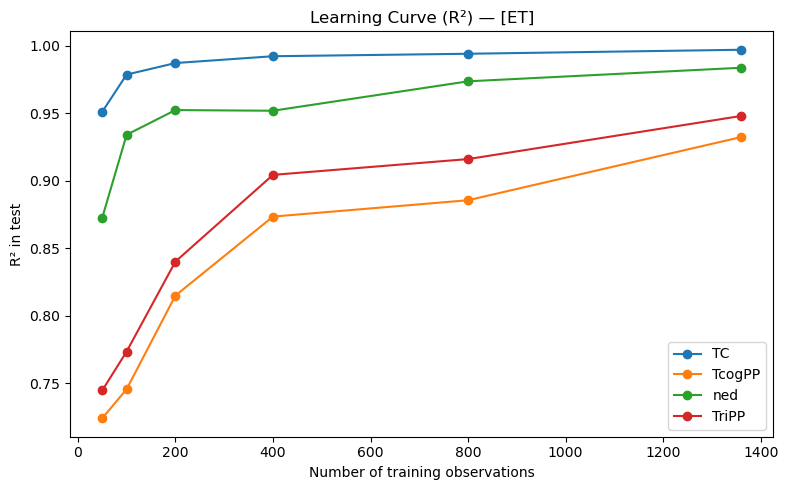

Saved: ./Datos/Transformados/Optimizacion\modelos_surrogates\figures\learning_R2_all_targets.png


In [8]:
# =========================================
# (NUEVO) Curva de aprendizaje conjunta (R²)
# =========================================

plt.figure(figsize=(8,5))

for objetivo in Y_cols:
    sub = learning_df[learning_df["target"] == objetivo]
    plt.plot(sub["n_train"], sub["R2"], marker="o", label=objetivo)

plt.xlabel("Number of training observations")
plt.ylabel("R² in test")
plt.title(f"Learning Curve (R²) — [{nombre_modelo_sonda}]")
plt.legend()
plt.tight_layout()

ruta_fig = os.path.join(FIG_DIR, "learning_R2_all_targets.png")
plt.savefig(ruta_fig, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", ruta_fig)

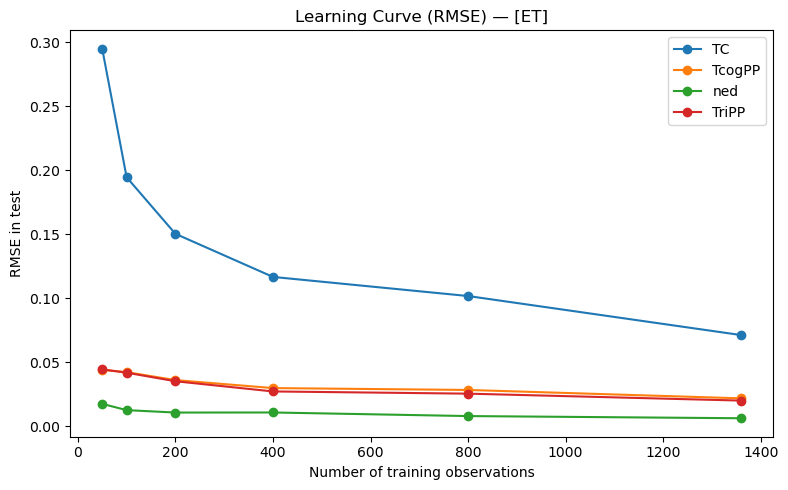

Saved: ./Datos/Transformados/Optimizacion\modelos_surrogates\figures\learning_RMSE_all_targets.png


In [9]:
# =========================================
# (NUEVO) Curva de aprendizaje conjunta (RMSE)
# =========================================

plt.figure(figsize=(8,5))

for objetivo in Y_cols:
    sub = learning_df[learning_df["target"] == objetivo]
    plt.plot(sub["n_train"], sub["RMSE"], marker="o", label=objetivo)

plt.xlabel("Number of training observations")
plt.ylabel("RMSE in test")
plt.title(f"Learning Curve (RMSE) — [{nombre_modelo_sonda}]")
plt.legend()
plt.tight_layout()

ruta_fig = os.path.join(FIG_DIR, "learning_RMSE_all_targets.png")
plt.savefig(ruta_fig, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", ruta_fig)

## 5) Entrenamiento + selección del mejor por objetivo

In [10]:
nombres_objetivo = Y_cols

filas_resultados = []
mejores_modelos = {}
mejores_metricas = {}
mejor_info_modelo = {}

N_ITER = 18
CV_FOLDS = 3

for idx_objetivo, nombre_objetivo in enumerate(nombres_objetivo):
    y_entren = Y_train[:, idx_objetivo]
    y_prueba = Y_test[:, idx_objetivo]

    print(f"\n==============================")
    print(f"Target: {nombre_objetivo}")
    print(f"==============================")

    puntuaciones_base = {}
    for nombre_modelo, pipe in modelos_base.items():
        modelo = clone(pipe)
        modelo.fit(X_train, y_entren)
        pred_prueba = modelo.predict(X_test)
        metricas = metricas_eval(y_prueba, pred_prueba)
        puntuaciones_base[nombre_modelo] = (modelo, metricas)

        filas_resultados.append({"target": nombre_objetivo, "model": f"{nombre_modelo}_baseline", **metricas})
        print(f"{nombre_modelo}_baseline -> {metricas}")

    base_ordenados = sorted(puntuaciones_base.items(), key=lambda kv: kv[1][1]["RMSE"])
    top2 = [base_ordenados[0][0], base_ordenados[1][0]]
    print("Top2 baselines to tune:", top2)

    candidatos_ajustados = []
    for nombre_modelo in top2:
        pipe = clone(modelos_base[nombre_modelo])

        busqueda = RandomizedSearchCV(
            estimator=pipe,
            param_distributions=espacios_busqueda[nombre_modelo],
            n_iter=N_ITER,
            scoring="neg_root_mean_squared_error",
            cv=CV_FOLDS,
            random_state=RANDOM_SEED,
            n_jobs=-1,
            verbose=0
        )
        busqueda.fit(X_train, y_entren)
        modelo_ajustado = busqueda.best_estimator_
        pred_prueba = modelo_ajustado.predict(X_test)
        metricas = metricas_eval(y_prueba, pred_prueba)

        filas_resultados.append({"target": nombre_objetivo, "model": f"{nombre_modelo}_tuned", **metricas})
        candidatos_ajustados.append((modelo_ajustado, metricas, f"{nombre_modelo}_tuned", busqueda.best_params_))

        print(f"{nombre_modelo}_tuned -> {metricas}")
        print("  best_params:", busqueda.best_params_)

    todos_candidatos = []
    for nombre_modelo, (modelo, metricas) in puntuaciones_base.items():
        todos_candidatos.append((modelo, metricas, f"{nombre_modelo}_baseline", None))
    todos_candidatos += candidatos_ajustados

    mejor = sorted(todos_candidatos, key=lambda x: x[1]["RMSE"])[0]
    mejores_modelos[nombre_objetivo] = mejor[0]
    mejores_metricas[nombre_objetivo] = mejor[1]
    mejor_info_modelo[nombre_objetivo] = {
        "modelo": mejor[2],
        "best_params": mejor[3]
    }
    print(f"--> BEST for {nombre_objetivo}: {mejor[2]} | {mejor[1]}")

metrics_df = pd.DataFrame(filas_resultados).sort_values(["target", "RMSE"])
display(metrics_df)

os.makedirs(OUT_DIR, exist_ok=True)
metrics_path = os.path.join(OUT_DIR, "surrogate_metrics.csv")
metrics_df.to_csv(metrics_path, index=False)
print("Saved:", metrics_path)

# Alias para mantener compatibilidad con el resto del notebook
target_names = nombres_objetivo
results_rows = filas_resultados
best_models = mejores_modelos
best_metrics = mejores_metricas


Target: TC
RF_baseline -> {'MAE': 0.045549401742647905, 'RMSE': 0.08920400881911264, 'R2': 0.9955336451837022}
ET_baseline -> {'MAE': 0.0316407389657002, 'RMSE': 0.07307511426340206, 'R2': 0.9970027464473767}
GB_baseline -> {'MAE': 0.048051979815939165, 'RMSE': 0.07399806432464325, 'R2': 0.9969265567657151}
Top2 baselines to tune: ['ET', 'GB']
ET_tuned -> {'MAE': 0.030960595852688295, 'RMSE': 0.07261723267745376, 'R2': 0.9970401897713129}
  best_params: {'model__n_estimators': 700, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 0.7, 'model__max_depth': 24}
GB_tuned -> {'MAE': 0.019357659669994122, 'RMSE': 0.033790853538964494, 'R2': 0.9993591110239536}
  best_params: {'model__subsample': 0.85, 'model__n_estimators': 1100, 'model__max_depth': 3, 'model__learning_rate': 0.08}
--> BEST for TC: GB_tuned | {'MAE': 0.019357659669994122, 'RMSE': 0.033790853538964494, 'R2': 0.9993591110239536}

Target: TcogPP
RF_baseline -> {'MAE': 0.009244182160679288, 'R

,target,model,MAE,RMSE,R2
4,TC,GB_tuned,0.019358,0.033791,0.999359
3,TC,ET_tuned,0.030961,0.072617,0.997040
1,TC,ET_baseline,0.031641,0.073075,0.997003
2,TC,GB_baseline,0.048052,0.073998,0.996927
0,TC,RF_baseline,0.045549,0.089204,0.995534
6,TcogPP,ET_baseline,0.007366,0.021758,0.932609
8,TcogPP,ET_tuned,0.007376,0.021895,0.931759
5,TcogPP,RF_baseline,0.009244,0.025676,0.906151
9,TcogPP,RF_tuned,0.008951,0.025693,0.906028
7,TcogPP,GB_baseline,0.017278,0.032688,0.847896


Saved: ./Datos/Transformados/Optimizacion\modelos_surrogates\surrogate_metrics.csv


## 6) Parity plots (y_true vs y_pred)

TC best metrics: {'MAE': 0.019357659669994122, 'RMSE': 0.033790853538964494, 'R2': 0.9993591110239536}
TcogPP best metrics: {'MAE': 0.0073659889289217515, 'RMSE': 0.021757766284601167, 'R2': 0.9326092047023532}
ned best metrics: {'MAE': 0.003049326676715634, 'RMSE': 0.00602576987847933, 'R2': 0.9848740921788672}
TriPP best metrics: {'MAE': 0.007054880151260902, 'RMSE': 0.020045481644949535, 'R2': 0.9480084824788532}


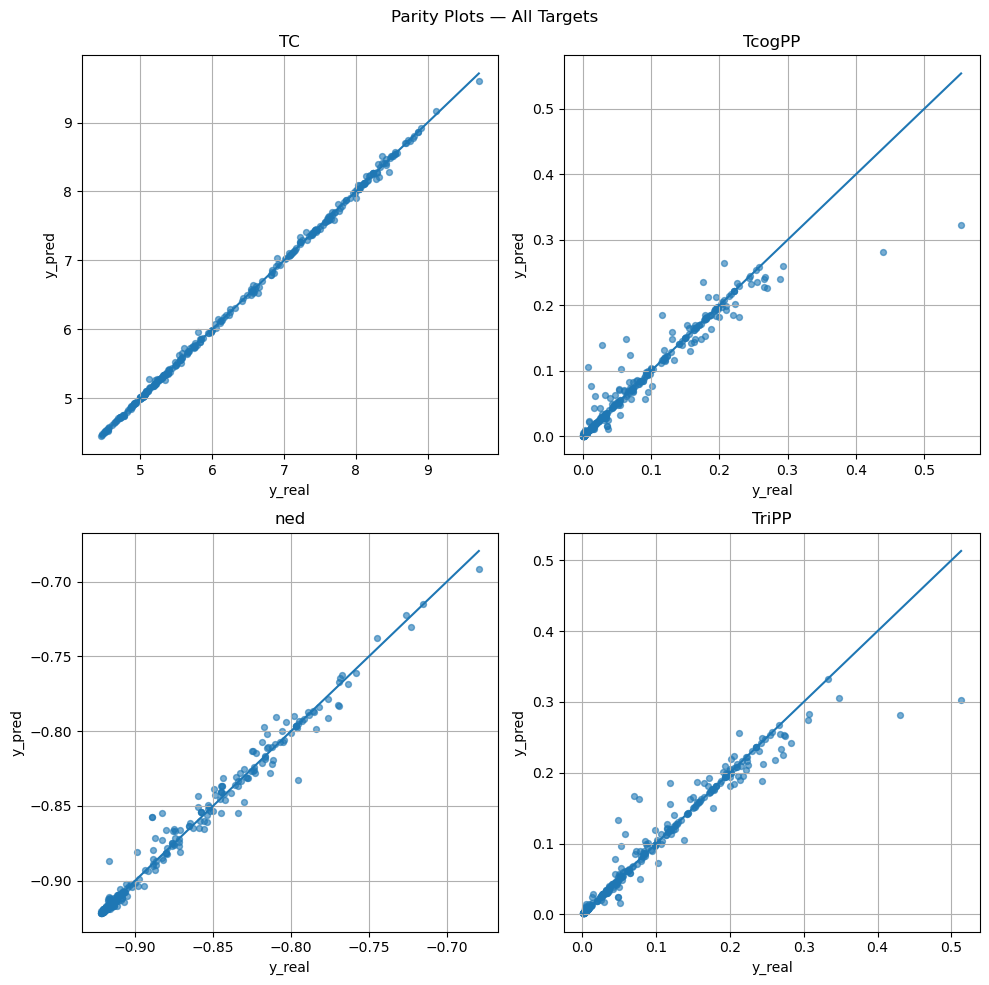

Saved: ./Datos/Transformados/Optimizacion\modelos_surrogates\figures\parity_all_targets.png


In [11]:
def parity_plots_all(Y_test, X_test, best_models, target_names, FIG_DIR):

    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    axes = axes.ravel()

    for idx_objetivo, nombre_objetivo in enumerate(target_names):

        ax = axes[idx_objetivo]

        modelo = best_models[nombre_objetivo]

        y_prueba = Y_test[:, idx_objetivo]
        pred = modelo.predict(X_test)

        metricas = metricas_eval(y_prueba, pred)
        print(f"{nombre_objetivo} best metrics:", metricas)

        # Scatter
        ax.scatter(y_prueba, pred, s=18, alpha=0.6)

        # Línea ideal y=x
        mn = min(np.min(y_prueba), np.min(pred))
        mx = max(np.max(y_prueba), np.max(pred))

        ax.plot([mn, mx], [mn, mx])

        ax.set_title(nombre_objetivo)
        ax.set_xlabel("y_real")
        ax.set_ylabel("y_pred")

        ax.grid(True)

    fig.suptitle("Parity Plots — All Targets")

    plt.tight_layout()

    ruta_fig = os.path.join(FIG_DIR, "parity_all_targets.png")

    plt.savefig(ruta_fig, dpi=200, bbox_inches="tight")

    plt.show()

    print("Saved:", ruta_fig)


# Ejecutar
parity_plots_all(
    Y_test,
    X_test,
    best_models,
    target_names,
    FIG_DIR
)

## 7) Guardado de modelos + metadatos (`models.pkl`)

In [12]:
artifact = {
    "models": best_models,
    "X_cols": X_cols,
    "Y_cols": Y_cols,
    "bounds": bounds,
    "random_seed": RANDOM_SEED,
    "notes": {
        "objectives_are_minimization": True,
        "ned_is_negative_efficiency": True
    }
}

os.makedirs(MODEL_DIR, exist_ok=True)

# Guardar cada mejor modelo por separado
for nombre_objetivo, modelo in best_models.items():
    ruta_modelo = os.path.join(MODEL_DIR, f"modelo_{nombre_objetivo}.joblib")
    joblib.dump(modelo, ruta_modelo)
    print("Saved:", ruta_modelo)

# Guardar también un artefacto global con metadatos
model_path = os.path.join(MODEL_DIR, "models.pkl")
joblib.dump(artifact, model_path)

info_path = os.path.join(MODEL_DIR, "best_models_info.json")
with open(info_path, "w", encoding="utf-8") as f:
    json.dump(mejor_info_modelo, f, ensure_ascii=False, indent=2)

print("Saved:", model_path)
print("Saved:", info_path)
print("Targets saved:", list(best_models.keys()))

Saved: ./Datos/Transformados/Optimizacion\models\surrogates\modelo_TC.joblib
Saved: ./Datos/Transformados/Optimizacion\models\surrogates\modelo_TcogPP.joblib
Saved: ./Datos/Transformados/Optimizacion\models\surrogates\modelo_ned.joblib
Saved: ./Datos/Transformados/Optimizacion\models\surrogates\modelo_TriPP.joblib
Saved: ./Datos/Transformados/Optimizacion\models\surrogates\models.pkl
Saved: ./Datos/Transformados/Optimizacion\models\surrogates\best_models_info.json
Targets saved: ['TC', 'TcogPP', 'ned', 'TriPP']


## 8) Resumen para el informe

In [13]:
resumen_mejores = []
for objetivo in target_names:
    resumen_mejores.append({
        "target": objetivo,
        "best_model": mejor_info_modelo[objetivo]["modelo"],
        **best_metrics[objetivo]
    })

best_summary_df = pd.DataFrame(resumen_mejores).sort_values("target")
display(best_summary_df)

os.makedirs(OUT_DIR, exist_ok=True)
best_summary_path = os.path.join(OUT_DIR, "best_models_summary.csv")
best_summary_df.to_csv(best_summary_path, index=False)
print("Saved:", best_summary_path)

,target,best_model,MAE,RMSE,R2
0,TC,GB_tuned,0.019358,0.033791,0.999359
1,TcogPP,ET_baseline,0.007366,0.021758,0.932609
3,TriPP,ET_tuned,0.007055,0.020045,0.948008
2,ned,RF_baseline,0.003049,0.006026,0.984874


Saved: ./Datos/Transformados/Optimizacion\modelos_surrogates\best_models_summary.csv
